In [1]:
include_barmer =  False

# we want to get the normalized expressions after batchcorrections
- we will not include the QC steps for now

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os, sys
import scanpy as sc
import pandas as pd
import scvi 

print("Last run with scvi-tools version:", scvi.__version__)

Last run with scvi-tools version: 1.2.2.post2


In [3]:
dataloc = "/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files_OLD/snRNAseq_LCNE_with_chrom.h5ad"
adata_sc_orig = sc.read_h5ad(dataloc)
adata_sc_orig.obs['actualsex'].value_counts()

actualsex
M    2595
F    2300
Name: count, dtype: int64

In [4]:
mask_xy = adata_sc_orig.var["chromosome"].isin(["X",'Y'])
mask_mt = adata_sc_orig.var["chromosome"].isin(["MT"])
mask_nan_chrom = adata_sc_orig.var["chromosome"].isna()
mask_xy_or_nan_or_mt = mask_xy | mask_nan_chrom | mask_mt

print(adata_sc_orig.shape[1],'before removing genes')
adata_sc_orig = adata_sc_orig[:, ~mask_xy_or_nan_or_mt.fillna(False)].copy()
print(adata_sc_orig.shape[1],'after removing genes')

29617 before removing genes
26473 after removing genes


In [5]:
if include_barmer:
    barseq_datapath = '/home/shuonan.chen/scratch_shuonan/scripts/LC_NE_dataintegration/BARseq/data/LCNE_barseq_counts_updated.csv'
    df = pd.read_csv(barseq_datapath)
    barseq_genes = df.iloc[:,0].tolist()
    barseq_genes = list(set(barseq_genes).intersection(adata_sc_orig.var_names))

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

var_names = adata_mer.var_names.intersection(adata_sc_orig.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 


In [6]:
adata_sc_orig.shape


(4895, 26473)

In [7]:
adata_sc_orig.raw = adata_sc_orig.copy()

adata_sc_orig.layers["CPM"] = adata_sc_orig.X.copy()
sc.pp.normalize_total(adata_sc_orig, target_sum=1e6, layer="CPM")
adata_sc_orig.layers["log(CPM)"] = adata_sc_orig.layers["CPM"].copy()
sc.pp.log1p(adata_sc_orig, layer="log(CPM)")

# two ways to do the HVG
1. CPM with seurat v3 (normalized)
2. log CPM with seurat 

In [8]:
adata_sc_orig.X.max()

np.float64(5984.0)

In [9]:
sc.pp.highly_variable_genes(adata_sc_orig, n_top_genes=1500, 
                            flavor="seurat_v3",  # default is seurat 
                            subset=True)
hvg_genes = adata_sc_orig.var_names[adata_sc_orig.var['highly_variable']].tolist()
genes_to_keep = list(set(hvg_genes))

if include_barmer:
    genes_to_keep = list(set(hvg_genes) | set(adata_mer.var_names.tolist()) | set(barseq_genes))
else:
    genes_to_keep = list(set(hvg_genes))

print(len(genes_to_keep))  # 1769 or 1500 for now!

    

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


1500


In [10]:
np.sum(['Gm' in g for g in genes_to_keep])

np.int64(290)

In [11]:
# save raw, and change the observations columns etc
raw_adata = adata_sc_orig.raw.to_adata()
adata_sc = raw_adata[:, genes_to_keep].copy()
totalcounts = np.sum(adata_sc.X, -1)
adata_sc.obs['totalcounts']=totalcounts
def batch_flag(x):
    # 1 for concatenated long strings, 0 for simple M/F
    return 1 if ';' in x else 2
adata_sc.obs['experimental_batch_id'] = adata_sc.obs['sex'].apply(batch_flag).astype('O')
adata_sc.X = adata_sc.X.tocsr() # do this for the faster scvi implementation!

In [12]:
scvi.settings.seed = 1
scvi.model.SCVI.setup_anndata(adata_sc, batch_key='sex')
model = scvi.model.SCVI(adata_sc, n_layers=1, n_latent=4, gene_likelihood="zinb")
model.train()

[rank: 0] Seed set to 1
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/aind/scratch/shuonan.chen/conda_envs/torch_on ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/aind/scratch/shuonan.chen/conda_envs/torch_on ...
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize the

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [13]:
SCVI_LATENT_KEY = "X_scVI"
adata_sc.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

In [14]:
sc.pp.neighbors(adata_sc, use_rep=SCVI_LATENT_KEY, n_neighbors=15, random_state=210)
sc.tl.umap(adata_sc,random_state=210)
sc.tl.leiden(adata_sc,resolution = .5,random_state=210)

/scratch/fast/9967989/ipykernel_2900928/4066772220.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_sc,resolution = .5,random_state=210)


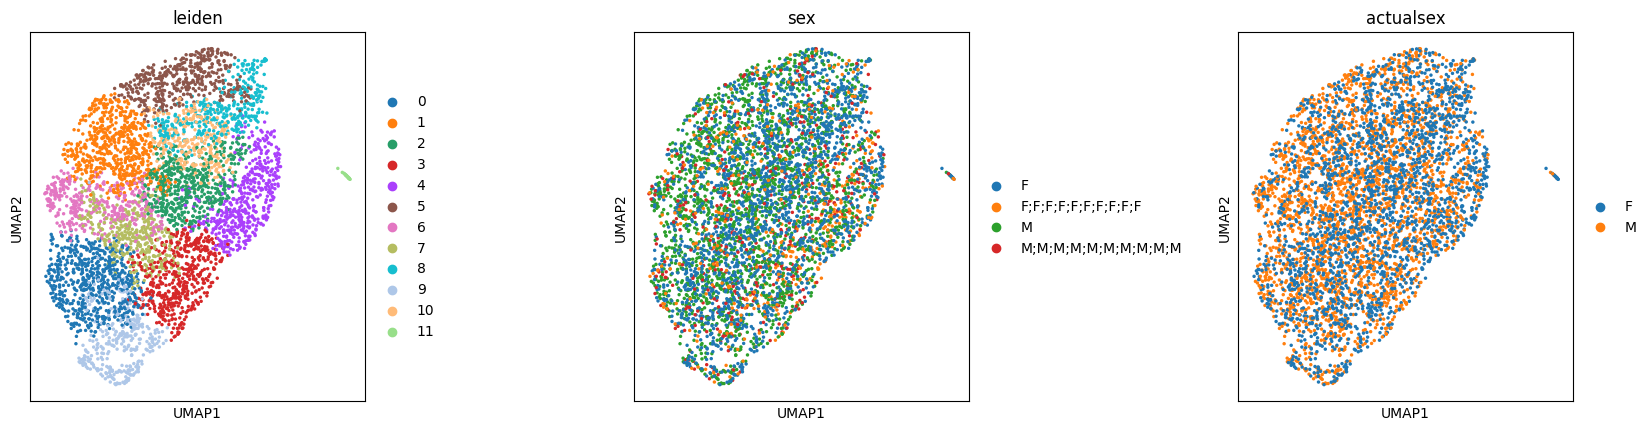

In [15]:
ax = sc.pl.umap(
    adata_sc,color=["leiden", "sex",'actualsex'],
    ncols=3,show = False)
for a in ax:
    a.set_aspect('equal')

# get the batch average normalized expression counts
- Denoised expression with batch “removed”

In [38]:
all_batches = model.adata_manager.get_state_registry("batch").categorical_mapping.tolist()
print(all_batches)

['F', 'F;F;F;F;F;F;F;F;F;F', 'M', 'M;M;M;M;M;M;M;M;M;M']


In [39]:
X_hat_avg = model.get_normalized_expression(
    adata=adata_sc,
    transform_batch=all_batches,    
    library_size= 1, # we wont change this to 1e+6 here for now
    return_numpy=False
)  
import anndata
adata_sc_BN = anndata.AnnData(X_hat_avg.copy())
adata_sc_BN.obs = adata_sc.obs.copy()
adata_sc_BN.obsm = adata_sc.obsm.copy()
adata_sc_BN.var = adata_sc.var.copy()

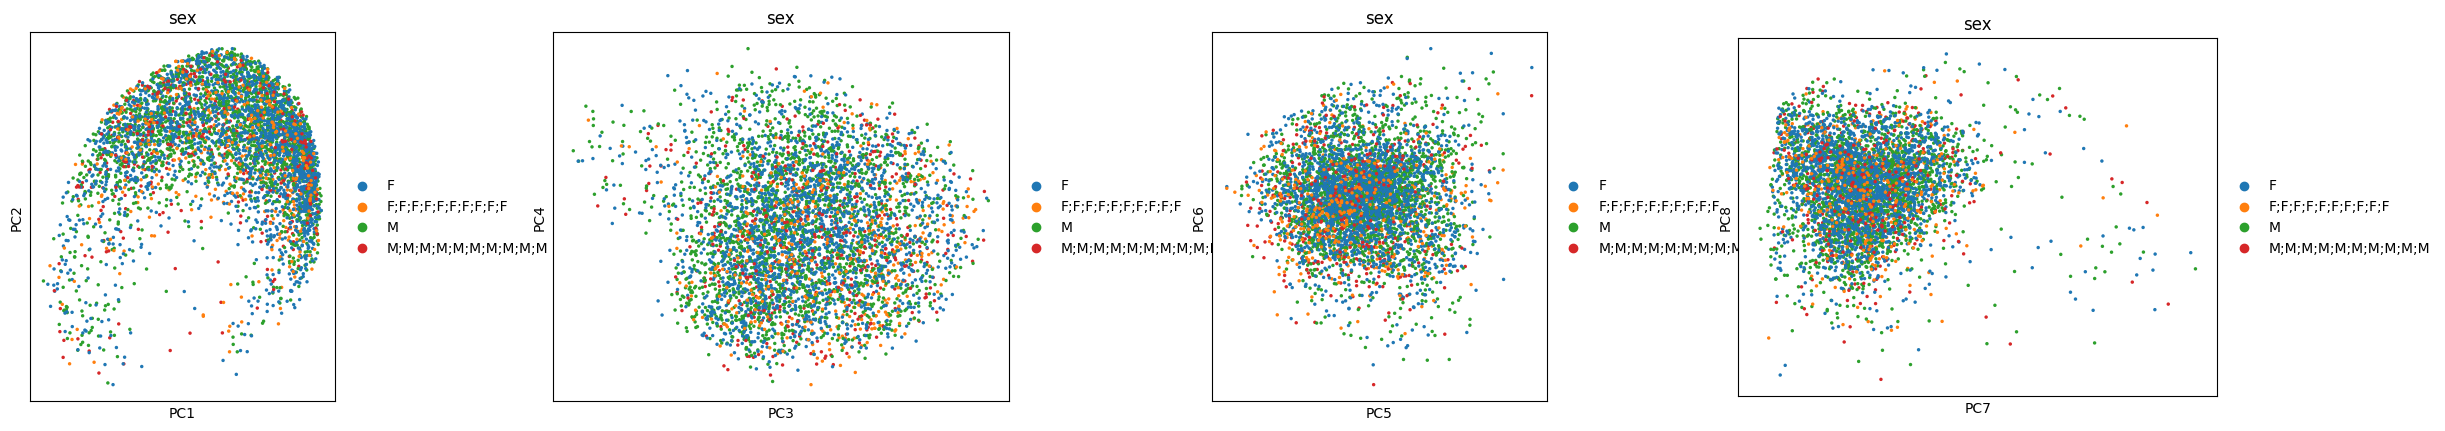

In [40]:
# standardize teh X for each genes
adata_sc_BN.X -= np.mean(adata_sc_BN.X, 0)
std_gene = np.std(adata_sc_BN.X, 0)
adata_sc_BN.X /= std_gene
sc.tl.pca(adata_sc_BN)
ax = sc.pl.pca(adata_sc_BN, dimensions=((0, 1), (2, 3), (4, 5), (6, 7)), show=False, color='sex')
for a in ax: a.set_aspect('equal')
plt.show()


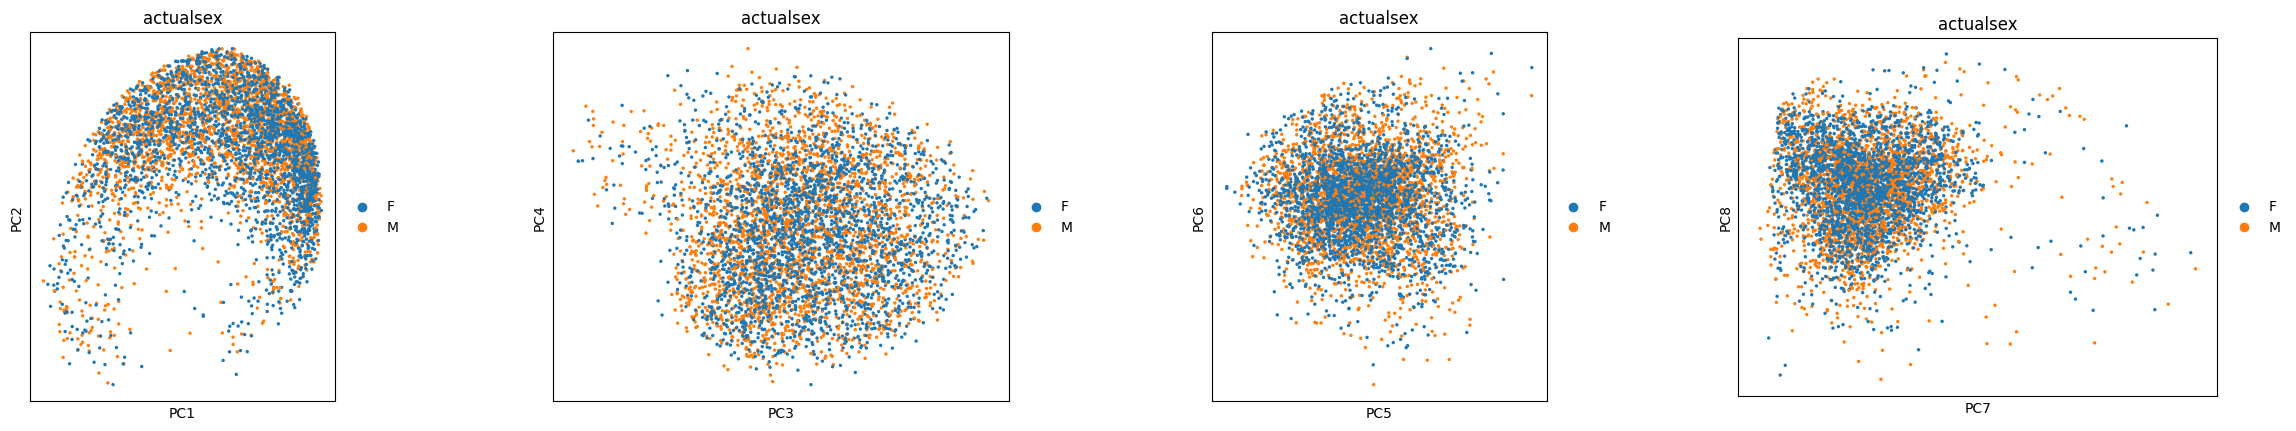

In [41]:
ax = sc.pl.pca(adata_sc_BN, dimensions=((0, 1), (2, 3), (4, 5), (6, 7)), show=False, color='actualsex')
for a in ax: a.set_aspect('equal')
plt.show()

# binary classification score 

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_score

In [35]:

X_pca = np.asarray(adata_sc_BN.obsm['X_pca'])
X_scvi = np.asarray(adata_sc_BN.obsm[SCVI_LATENT_KEY])

y = (np.asarray(adata_sc_BN.obs['actualsex']) == 'F').astype(int)

for X in [X_pca, X_scvi]:
    
    print('=====')
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000))
    clf.fit(Xtr, ytr)
    p = clf.predict_proba(Xte)[:, 1]
    yhat = (p >= 0.5).astype(int)
    print("accuracy:", accuracy_score(yte, yhat))
    print("roc_auc:", roc_auc_score(yte, p))
    print("confusion_matrix:\n", confusion_matrix(yte, yhat))
    
    
    scores = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                             X, y, cv=5, scoring="roc_auc")
    print("cv_roc_auc_mean:", scores.mean())


=====
accuracy: 0.5413687436159347
roc_auc: 0.5418614392225852
confusion_matrix:
 [[342 177]
 [272 188]]
cv_roc_auc_mean: 0.5302789645639608
=====
accuracy: 0.5566905005107252
roc_auc: 0.5341208008712407
confusion_matrix:
 [[424  95]
 [339 121]]
cv_roc_auc_mean: 0.5282751109994136


In [36]:
(np.sum(adata_sc.X, axis = 0)<3).sum()

np.int64(80)

# save 
- the normalized counts are saved as `BN` layer
- for now we keep 1e+6 

In [28]:
cpm_scl= 1
adata_sc.layers["BN"] = X_hat_avg*cpm_scl

In [33]:
filename = 'snRNAseq_LCNE_BN_d4_merbar_1-5k.h5ad' if include_barmer else 'snRNAseq_LCNE_BN_d4_1-5k.h5ad' 
# adata_sc.write(f"/home/shuonan.chen/scratch_shuonan/LC_scRNAseq/processed_data/{filename}")
adata_sc.obs['experimental_batch_id'] = adata_sc.obs['experimental_batch_id'].astype(str)
# you might as well save them in the actual repo!!
adata_sc.write(f"/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/data/{filename}")


In [34]:
(np.sum(adata_sc.X, axis = 0)<3).sum()

np.int64(0)

In [35]:
filename

'snRNAseq_LCNE_BN_d4_1-5k.h5ad'